In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np

In [2]:
train_data = pd.read_csv('regression/square-simple-training.csv', index_col=0)
test_data = pd.read_csv('regression/square-simple-test.csv', index_col=0)
print(train_data.shape)
train_data.head()


(100, 2)


,x,y
1,-0.171543,-127.351580
2,0.025201,-129.942844
3,-1.368991,38.672367
4,1.907390,197.432191
5,0.011129,-129.988852


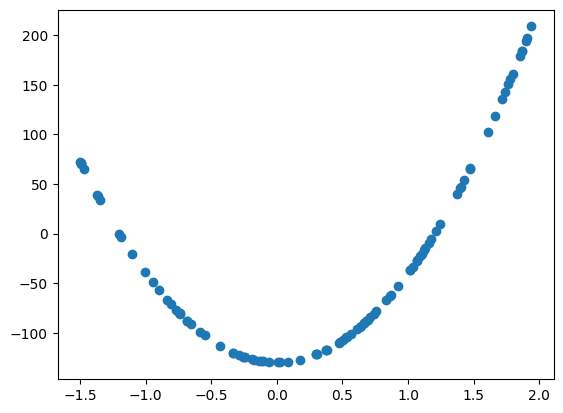

In [3]:
import matplotlib.pyplot as plt
plt.scatter(train_data['x'], train_data['y'])

In [4]:
mi = train_data.mean()
std = train_data.std()
train_data = (train_data - mi) / std
test_data = (test_data - mi) / std

In [5]:
X_train = torch.tensor(train_data['x'].values, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(train_data['y'].values, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(test_data['x'].values, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(test_data['y'].values, dtype=torch.float32).unsqueeze(1)

In [6]:
from sklearn.metrics import mean_squared_error
def model_train(hidden_size = 5, no_of_layers = 1,iters = 100, learning_rate = 0.001):
    model = nn.Sequential(nn.Linear(1, hidden_size))
    for i in range(no_of_layers):
        model.append(nn.Sigmoid())
        if i == no_of_layers - 1:
            model.append(nn.Linear(hidden_size, 1))
        else:
            model.append(nn.Linear(hidden_size, hidden_size))
    loss = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    device = 'cpu'
    model.to(device)
    for epoch in range(iters):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        lo = loss(y_pred, y_train)
        lo.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test.unsqueeze(1))
    mse_y = y_pred_test.numpy().flatten() * std['y'] + mi['y']
    mse_y_pred = y_test.numpy().flatten() * std['y'] + mi['y']
    mse = mean_squared_error(mse_y, mse_y_pred)
    print(f"MSE: {mse}, learning rate: {learning_rate}")
    return mse, model, y_pred_test.numpy().flatten()

In [7]:
models = []
for i in np.linspace(0.001, 1, 20):
    mse, model,y_pred51 = model_train(hidden_size=5, no_of_layers=1, iters=1000, learning_rate=i)
    models.append((mse, model, y_pred51))
idx = np.argmin([m[0] for m in models])
best_model_5_1 = models[idx][1]
y_pred51 = models[idx][2]

MSE: 2978.475997059613, learning rate: 0.001
MSE: 5.96072262068051, learning rate: 0.05357894736842105
MSE: 2.193135025912246, learning rate: 0.1061578947368421
MSE: 1.1710323749195402, learning rate: 0.15873684210526315
MSE: 1.2714268468641503, learning rate: 0.2113157894736842
MSE: 2.0225414559887773, learning rate: 0.26389473684210524
MSE: 31.0538382163402, learning rate: 0.3164736842105263
MSE: 0.4704747398441691, learning rate: 0.36905263157894735
MSE: 10.572128013185791, learning rate: 0.4216315789473684
MSE: 0.8324166598814958, learning rate: 0.47421052631578947
MSE: 1.4615745628922583, learning rate: 0.5267894736842105
MSE: 10.215308478308724, learning rate: 0.5793684210526315
MSE: 10.407819979367453, learning rate: 0.6319473684210526
MSE: 1.6284954367429756, learning rate: 0.6845263157894736
MSE: 2.5379050040698434, learning rate: 0.7371052631578947
MSE: 9.175982705083552, learning rate: 0.7896842105263158
MSE: 2.132768496406783, learning rate: 0.8422631578947368
MSE: 9.181244

In [8]:
for i in np.linspace(0.001, 1, 20):
    mse, model,y_pred101 = model_train(hidden_size=10, no_of_layers=1, iters=1000, learning_rate=i)
    models.append((mse, model, y_pred101))
idx = np.argmin([m[0] for m in models])
best_model_10_1 = models[idx][1]
y_pred101 = models[idx][2]

MSE: 2251.432269887564, learning rate: 0.001
MSE: 1.6792797420991166, learning rate: 0.05357894736842105
MSE: 0.28808513759869125, learning rate: 0.1061578947368421
MSE: 0.3208006878722695, learning rate: 0.15873684210526315
MSE: 3.6540380256666305, learning rate: 0.2113157894736842
MSE: 0.68137228514828, learning rate: 0.26389473684210524
MSE: 0.23840289683270324, learning rate: 0.3164736842105263
MSE: 3.526018997255996, learning rate: 0.36905263157894735
MSE: 1.7623831789251083, learning rate: 0.4216315789473684
MSE: 3.3100022860124447, learning rate: 0.47421052631578947
MSE: 12.939134088487362, learning rate: 0.5267894736842105
MSE: 2.2974476438101865, learning rate: 0.5793684210526315
MSE: 0.5492593665871147, learning rate: 0.6319473684210526
MSE: 3.3876364550776485, learning rate: 0.6845263157894736
MSE: 0.3968132940458847, learning rate: 0.7371052631578947
MSE: 1.62769257348295, learning rate: 0.7896842105263158
MSE: 87.73165060089373, learning rate: 0.8422631578947368
MSE: 1.557

In [9]:
models = []
for i in np.linspace(0.0001, 0.1, 20):
    mse, model, y_pred52 = model_train(hidden_size=5, no_of_layers=2, iters=1000, learning_rate=i)
    models.append((mse, model, y_pred52))
idx = np.argmin([m[0] for m in models])
best_model_5_2 = models[idx][1]
y_pred52 = models[idx][2]

MSE: 7282.621396849414, learning rate: 0.0001
MSE: 39.04984043418557, learning rate: 0.005357894736842106
MSE: 10.194914518070977, learning rate: 0.01061578947368421
MSE: 1.2431505940777272, learning rate: 0.015873684210526314
MSE: 5.233385104089177, learning rate: 0.02113157894736842
MSE: 1.443240332412317, learning rate: 0.02638947368421053
MSE: 1.1811301432703019, learning rate: 0.03164736842105263
MSE: 1723.8055280618357, learning rate: 0.03690526315789474
MSE: 1722.6361749585744, learning rate: 0.04216315789473685
MSE: 0.9872553315434561, learning rate: 0.047421052631578954
MSE: 2.015959899820446, learning rate: 0.05267894736842106
MSE: 1723.5603282383559, learning rate: 0.05793684210526316
MSE: 0.7483248932168113, learning rate: 0.06319473684210526
MSE: 0.6959106688019605, learning rate: 0.06845263157894738
MSE: 0.8109007558414045, learning rate: 0.07371052631578948
MSE: 2.0101764558074975, learning rate: 0.07896842105263159
MSE: 1727.6217334790997, learning rate: 0.0842263157894

In [10]:
for layer in best_model_5_2.children():
    if isinstance(layer, nn.Linear):
        print(layer.state_dict()['weight'].T)
        print(layer.state_dict()['bias'].T)

tensor([[ 3.5003, -2.2468, -2.3302,  2.0578, -2.6753]])
tensor([1.1549, 2.3249, 2.4922, 4.1574, 3.8544])
tensor([[ 2.0052,  2.9211,  1.8275, -0.6622, -4.1241],
        [-3.3173, -3.0415, -2.9663, -1.0241,  1.3867],
        [-3.7761, -3.5251, -3.1615, -1.3963,  1.3514],
        [ 1.3887,  2.9103,  1.3365, -0.4868, -6.9240],
        [-3.2809, -1.3106, -1.3856, -1.2114,  1.9214]])
tensor([-0.8625,  0.4846,  0.1685, -0.9456,  0.3710])
tensor([[1.9195],
        [1.5855],
        [1.6090],
        [0.2062],
        [3.1813]])
tensor([-1.2041])


C:\Users\wojtek\AppData\Local\Temp\ipykernel_27108\4277533457.py:4: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4483.)
  print(layer.state_dict()['bias'].T)


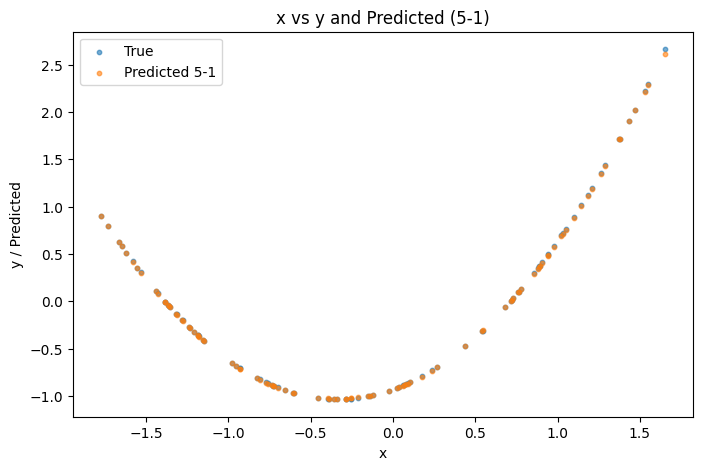

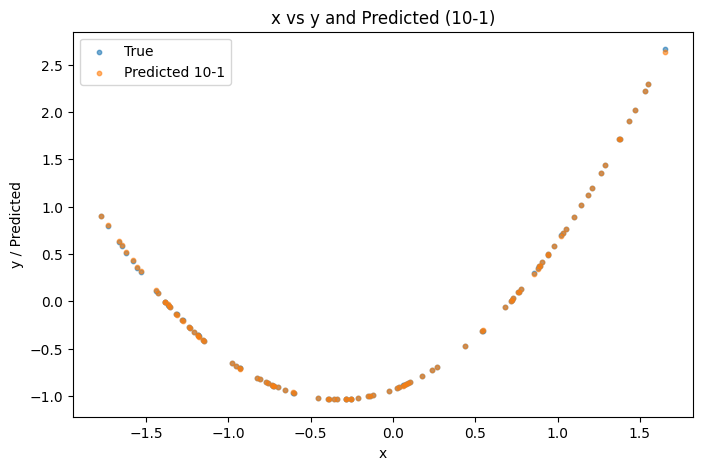

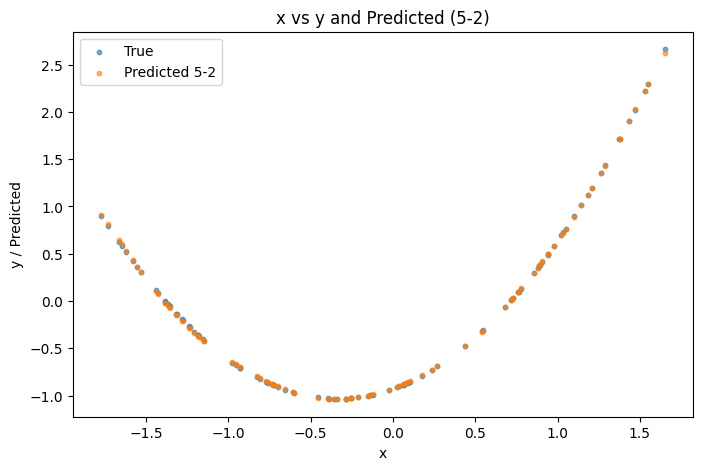

In [11]:
#wykresy wygenerowane z llm
plt.figure(figsize=(8, 5))
plt.scatter(test_data['x'], test_data['y'], s=10, alpha=0.6, label='True')
plt.scatter(test_data['x'], y_pred51, s=10, alpha=0.6, label='Predicted 5-1')
plt.xlabel('x')
plt.ylabel('y / Predicted')
plt.title('x vs y and Predicted (5-1)')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(test_data['x'], test_data['y'], s=10, alpha=0.6, label='True')
plt.scatter(test_data['x'], y_pred101, s=10, alpha=0.6, label='Predicted 10-1')
plt.xlabel('x')
plt.ylabel('y / Predicted')
plt.title('x vs y and Predicted (10-1)')
plt.legend()
plt.show()

# Plot: x vs y and x vs prediction for 5-2 model
plt.figure(figsize=(8, 5))
plt.scatter(test_data['x'], test_data['y'], s=10, alpha=0.6, label='True')
plt.scatter(test_data['x'], y_pred52, s=10, alpha=0.6, label='Predicted 5-2')
plt.xlabel('x')
plt.ylabel('y / Predicted')
plt.title('x vs y and Predicted (5-2)')
plt.legend()
plt.show()

In [24]:
from math import exp

class Value:
    def __init__(self, val, child=()):

        self.val = val
        self.grad = 0
        self.child = child
        self.back = lambda: None
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.val + other.val, (self, other))
        def back():
            self.grad += out.grad
            other.grad += out.grad
        out.back = back
        return out
    def __radd__(self, other):
        return self + other
    def __neg__(self):
        return self * -1
    def __sub__(self, other):
        return self + (-other)
    def __rsub__(self, other):
        return other + (-self)
    def __pow__(self, other):
        assert isinstance(other, (int, float)), f"potega musi byc float albo int a teraz jest: {type(other)}"
        out = Value(self.val**other, (self,))
        def back():
            self.grad += (other * self.val**(other-1)) * out.grad
        out.back = back
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.val * other.val, (self, other))
        def back():
            self.grad += other.val * out.grad
            other.grad += self.val * out.grad
        out.back = back
        return out
    def __rmul__(self, other):
        return self * other
    def __truediv__(self, other):
        return self * (other**(-1))
    def __rtruediv__(self, other):
        return other * (self**(-1))

    def sigmoid(self):
        x = self.val
        if x < -500: # obcinanie f. żeby uniknąć błędów numerycznych
            sig_val = 0.0
        elif x > 500:
            sig_val = 1.0
        else:
            sig_val = 1.0 / (1.0 + exp(-x))
        out = Value(sig_val, (self,))
        def back():
            self.grad += out.val*(1-out.val) * out.grad
        out.back = back
        return out
    
    def backward(self):
        topo = []
        vis = set()

        def build(v):
            if v not in vis:
                vis.add(v)
                for child in v.child:
                    build(child)
                topo.append(v)
        build(self)
        self.grad = 1
        for v in reversed(topo):
            v.back()
    def __repr__(self):
        return f"v:{self.val}, g:{self.grad}"


In [25]:

import random
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    def parameters(self):
        return []

class Neuron(Module):
    def __init__(self, no_in: int, nonlin:bool= True):
        self.w = [Value(random.gauss(0, (2/no_in)**0.5)) for _ in range(no_in)]
        self.b = Value(0)
        self.nonlin = nonlin
    
    def parameters(self):
        return self.w + [self.b]
    
    def __call__(self, x):
        suma = Value(0.0)
        for wi, xi in zip(self.w, x):
            suma += wi * xi
        suma += self.b
        if self.nonlin:
            return suma.sigmoid()
        else: return suma

class Layer(Module):
    def __init__(self, _in: int, _out:int, **kwargs:Neuron):
        self.neurons = [Neuron(_in, **kwargs) for _ in range(_out)]
    def __call__(self,x):
        out = [n(x) for n in self.neurons]
        if len(out) == 1:
            return out[0]
        else:
            return out
    def parameters(self):
        out =[]
        for n in self.neurons:
            for p in n.parameters():
                out.append(p)
        return out


class MLP(Module):
    def __init__(self, no_in: int, _outs: list[int]): # _outs jest tablicą przyjmującą wielkości kolejnych konkretnych warstw
        sizes = [no_in] + _outs
        self.layers = [Layer(sizes[i], sizes[i+1], nonlin=(i!= len(_outs)-1)) for i in range(len(_outs))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x) # TUTAJ FORWARD PASS jest zrobiony
        return x
    def parameters(self):
        out =[]
        for layer in self.layers:
            for p in layer.parameters():
                out.append(p)
        return out
# stworzone z pomocą repozytorium micrograd


In [26]:
def konwerter(state_dict, shape: list[int]):

    weights = [v.tolist() for k, v in state_dict.items() if 'weight' in k]
    biases = [v.tolist() for k, v in state_dict.items() if 'bias' in k]
    custom_weights = []
    for layer_idx in range(len(shape) - 1):
        n_out = shape[layer_idx + 1]
        W = weights[layer_idx]
        b = biases[layer_idx]
        for neuron_idx in range(n_out):
            custom_weights.extend(W[neuron_idx])
            custom_weights.append(b[neuron_idx])
    return custom_weights

In [27]:
model = MLP(1, [5, 5, 1])

state_dict = best_model_5_2.state_dict()
weights_list = konwerter(state_dict, [1, 5, 5, 1])


for p, weight_value in zip(model.parameters(), weights_list):
    p.val = float(weight_value)


test_input_single = [Value(float(test_data["x"].iloc[0]))]
test_output = model(test_input_single)


with torch.no_grad():
    pytorch_single = best_model_5_2(X_test[0:1]).item()


In [28]:
inputs = [[Value(float(x))] for x in test_data["x"]]
scores = list(map(model, inputs))

y_test_pred = []
for s in scores:
    y_test_pred.append(s.val)

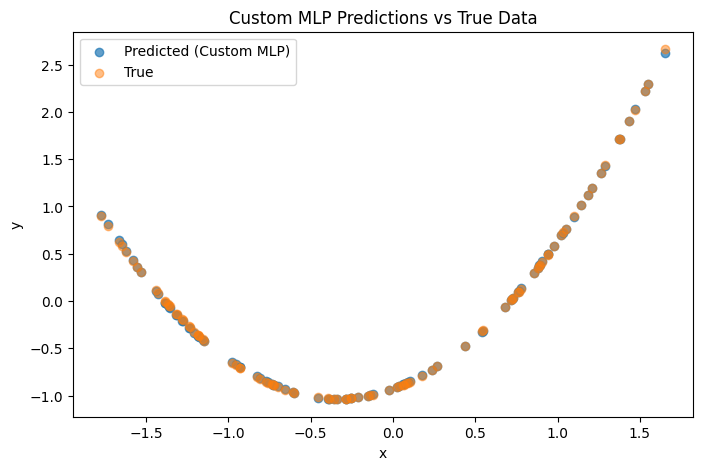

In [29]:
#wykresy z LLM
plt.figure(figsize=(8, 5))
plt.scatter(test_data["x"], y_test_pred, label='Predicted (Custom MLP)', alpha=0.7)
plt.scatter(test_data["x"], test_data["y"], label='True', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Custom MLP Predictions vs True Data')
plt.legend()
plt.show()

In [30]:
unnorm = test_data *std + mi



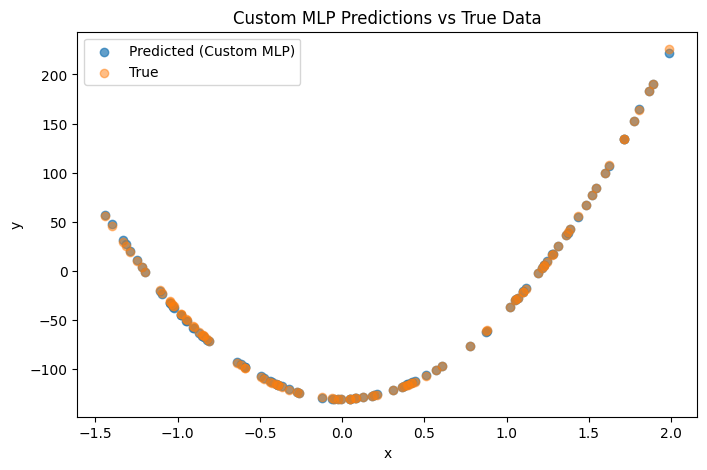

In [31]:
#wykresy z LLM
plt.figure(figsize=(8, 5))
plt.scatter(unnorm["x"], np.array(y_test_pred) * std['y'] + mi['y'], label='Predicted (Custom MLP)', alpha=0.7)
plt.scatter(unnorm["x"], unnorm["y"], label='True', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Custom MLP Predictions vs True Data')
plt.legend()
plt.show()

# backprop

In [32]:

# Trening custom MLP z propagacją wsteczną
model_bp = MLP(1, [5, 5, 1])
learning_rate = 0.05
iters = 1000
losses = []

X_train_list = train_data["x"].tolist()
y_train_list = train_data["y"].tolist()

for epoch in range(iters):
    # Forward pass dla całego zbioru treningowego
    inputs = [[Value(x)] for x in X_train_list]
    y_true = [Value(y) for y in y_train_list]

    preds = [model_bp(inp) for inp in inputs]

    # Strata MSE
    n = len(y_true)
    loss = sum((p - y) ** 2 for p, y in zip(preds, y_true)) * (1.0 / n)

    # Zerowanie gradientów przed backward
    model_bp.zero_grad()

    # Propagacja wsteczna
    loss.backward()

    # Aktualizacja wag (SGD)
    for p in model_bp.parameters():
        p.val -= learning_rate * p.grad

    losses.append(loss.val)
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.val:.6f}")

print(f"\nKońcowa strata: {losses[-1]:.6f}")


Epoch    0 | Loss: 0.914354
Epoch  100 | Loss: 0.818580
Epoch  200 | Loss: 0.724457
Epoch  300 | Loss: 0.630041
Epoch  400 | Loss: 0.532143
Epoch  500 | Loss: 0.442060
Epoch  600 | Loss: 0.367959
Epoch  700 | Loss: 0.309435
Epoch  800 | Loss: 0.261812
Epoch  900 | Loss: 0.220546

Końcowa strata: 0.183911


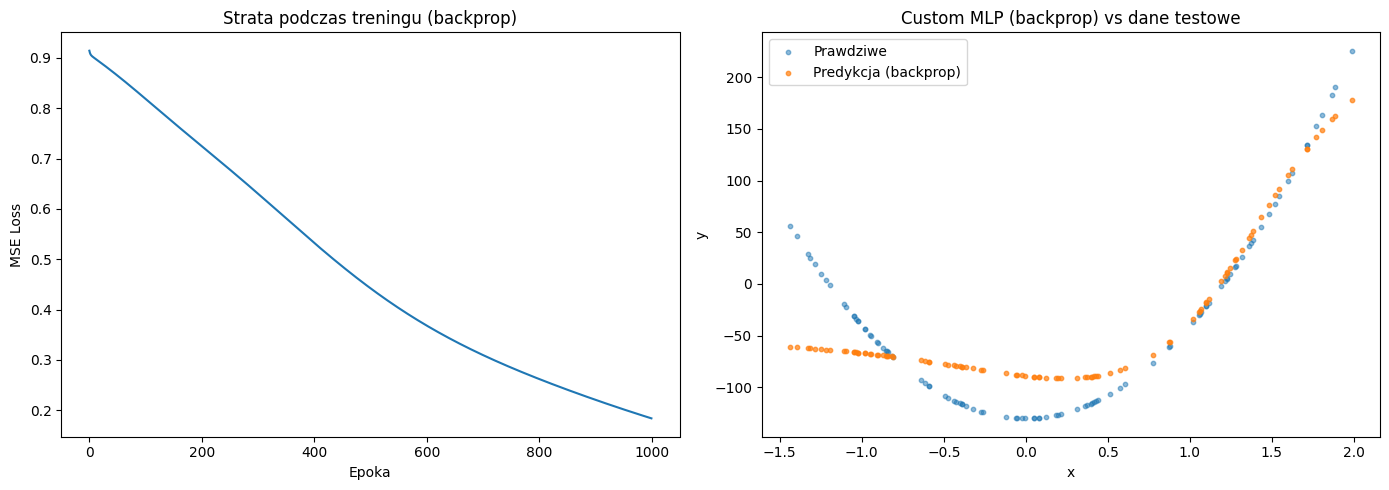

MSE (backprop, oryginalna skala): 1212.0387


In [ ]:

inputs_test = [[Value(float(x))] for x in test_data["x"]]
y_bp_pred = [model_bp(inp).val for inp in inputs_test]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Krzywa straty
axes[0].plot(losses)
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Strata podczas treningu (backprop)")

# Predykcje vs wartości rzeczywiste (w oryginalnej skali)
y_bp_orig = np.array(y_bp_pred) * std["y"] + mi["y"]
axes[1].scatter(unnorm["x"], unnorm["y"], s=10, alpha=0.5, label="Prawdziwe")
axes[1].scatter(unnorm["x"], y_bp_orig, s=10, alpha=0.7, label="Predykcja (backprop)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Custom MLP (backprop) vs dane testowe")
axes[1].legend()

plt.tight_layout()
plt.show()

mse_bp = mean_squared_error(unnorm["y"], y_bp_orig)
print(f"MSE (backprop, oryginalna skala): {mse_bp:.4f}")
